# 07. Transformer Architecture 

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2026-04-16">16 Apr 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/07_transformer.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following source was consulted in preparing this material:
  </p>
  <ul style="margin-top: 0;">
    <li>
      Zhang, A., Lipton, Z. C., Li, M., &amp; Smola, A. J.
      <a href="https://d2l.ai/">Dive into Deep Learning</a>. Cambridge University Press.
      <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html">Attention Mechanisms and Transformers</a>.
    </li>
  </ul>
</div>

This notebook builds the Transformer architecture step by step following the infamous _Attention is all you need_ paper ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). We begin with the limitation of fixed-context sequence-to-sequence models, move to attention as weighted retrieval, discuss self-attention, assemble multi-head attention, feed-forward layers, residual connections and normalization, the encoder block, the decoder block, and finally the full training and inference of Transformers.

## Attention

In the classical [encoder-decoder](../06_rnn_sequential#encoder-decoder-architecture) view of [sequence modeling](../06_rnn_sequential/#language-modeling), the encoder reads the whole source sequence and compresses it into one context vector:
$$
c = \operatorname{Encoder}(x_1, x_2, \dots, x_T),
\qquad
y_t = \operatorname{Decoder}(y_{<t}, c).
$$

<figure>
  <img src="../../assets/images/transformer/seq2seq-state.svg" alt="Sequence to Sequence (Seq2Seq) Layers" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Sequence-to-sequence (Seq2Seq) learning layers in encoder-decoder architecture. The state, as generated by the encoder, is the only piece of information shared between the encoder and the decoder. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-state.svg">Fig. 11.4.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

This is elegant, but it creates a bottleneck. The same vector $c$ must carry whatever information the decoder may need at every later step. For short inputs that can be enough. For longer or more detailed inputs, it is restrictive because the decoder cannot change what it retrieves from the source: it only keeps reusing the same summary. [Attention](<https://en.wikipedia.org/wiki/Attention_(machine_learning)>) changes this. Instead of one frozen context, the decoder modifies context depending on a step:
$$
c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i,
$$
where $h_i$ is the encoder representation at source position $i$ and $\alpha_{t,i}$ says how strongly step $t$ should use that position. So the model no longer asks the encoder for one final summary: it asks for a new weighted summary whenever the current prediction step needs one.  From a [linear algebra](../../mathematics/02_linear_algebra) point of view, attention is just learned weighted averaging. From a modeling point of view, it removes the fixed-summary bottleneck because the summary can change from one prediction step to the next. The next section will formalize this mechanism using the language of queries, keys, and values.

## Query, Key, Value

The formula from the previous section says that the decoder no longer uses the same frozen summary at every step. To make that idea precise, we now separate three roles. The current need of the model is represented by a *query*. The source (encoder)-side items that can be matched against that need are represented by *keys*. The actual pieces of information that will be mixed together are represented by *values*. This is why attention is often explained through the language of a database: a query is compared against keys, and the result tells us how strongly to retrieve the corresponding values. If the source-side collection is $D = \{(k_1, v_1), \dots, (k_m, v_m)\}$, then attention produces
$$
\operatorname{Attn}(q, D) = \sum_{i=1}^{m} \alpha(q, k_i) v_i.
$$
Here $q$ is the query, $k_i$ is the key for item $i$, $v_i$ is its value, and $\alpha(q, k_i)$ is the weight assigned to that item. So attention does not directly output one source vector. It outputs a weighted combination of values. The next two cells make this concrete with one query and four key-value pairs. The values are chosen to be especially easy to inspect, so the mechanics are visible before we move to the full matrix form.

In [3]:
import torch

tokens = ["the", "cat", "sat", "down"]

k = torch.eye(len(tokens))
v = k.clone()
q = torch.tensor([0.0, 0.2, 1.0, 0.8])

scores = q @ k.T
scores

ModuleNotFoundError: No module named 'torch'

<figure>
  <img src="../../assets/images/transformer/qkv.svg" alt="Sequence to Sequence (Seq2Seq) Layers" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    The attention mechanism computes a linear combination over values via attention pooling, where weights are derived according to the compatibility between a query and keys ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/queries-keys-values.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/qkv.svg">Fig. 11.1.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

Because the keys are the standard basis vectors, the [dot product](../../mathematics/02_linear_algebra/#vector-and-matrix-multiplications) between a query and each key simply picks out one coordinate of $q$. So the raw scores already tell us how compatible the query is with each source position. Larger scores mean stronger match. To turn these raw scores into usable attention weights, we normalize them with the [softmax function](../../mathematics/03_probability/#softmax) which creates [convex combination](https://en.wikipedia.org/wiki/Convex_combination) of the raw scores.

In [4]:
weights = torch.softmax(scores, dim=0)
context = weights @ v

weights, context

(tensor([0.1396, 0.1705, 0.3794, 0.3106]),
 tensor([0.1396, 0.1705, 0.3794, 0.3106]))

The result is especially transparent here because we deliberately set the values equal to the keys. For that reason, the context vector numerically matches the attention weights. That is not a general rule, it is just a clean teaching example. What matters is the pattern. The query places most weight on the third and fourth items, so the resulting context is shaped mostly by those values, which is the basic role of queries, keys, and values in attention: _the query says what the model is looking for now, the keys determine how strongly each item matches that need, and the values are the vectors that are actually combined._

## Masked Attention

We should note one important nuance here. Attention usually runs on batches of sequences, and those sequences often have different lengths. To place them in the same batch, we pad the shorter ones, similar to what we saw in the RNN lecture. As padded positions are not real tokens, attention should not assign weight to them. That is why we may need a **masked** version of the softmax function. If only the first $\ell$ positions are valid, then the masked version should normalize over those positions only and force the rest to zero:
$$
\alpha_i = \frac{e^{s_i}}{\sum_{j=1}^{\ell} e^{s_j}} \text{ for } i \leq \ell,
\qquad
\alpha_i = 0 \text{ for } i > \ell.
$$

In [5]:
# 0.0 represents padding here
scores = torch.tensor([
    [2.0, 1.0, 0.0, 0.0],
    [0.3, 1.4, 0.2, 0.0],
])

torch.softmax(scores, dim=-1)

tensor([[0.6103, 0.2245, 0.0826, 0.0826],
        [0.1770, 0.5317, 0.1602, 0.1311]])

Even though the first example should only use its first two positions and the second example should only use its first three, vanilla softmax still spreads some weight onto the padded positions. In a model it would allow meaningless padding tokens to influence the context vector. So we need to hide positions beyond the valid length before softmax is applied. The usual trick is simple: replace masked entries by a very large negative number. After exponentiation inside softmax, those entries contribute essentially zero.

In [6]:
valid_lens = torch.count_nonzero(scores, dim=-1) 
mask = torch.arange(scores.size(-1)) < valid_lens.unsqueeze(1)
masked_scores = scores.masked_fill(~mask, float('-inf')) # ~ is "not" operator

mask, masked_scores

(tensor([[ True,  True, False, False],
         [ True,  True,  True, False]]),
 tensor([[2.0000, 1.0000,   -inf,   -inf],
         [0.3000, 1.4000, 0.2000,   -inf]]))

In [7]:
weights = torch.softmax(masked_scores, dim=-1)
weights

tensor([[0.7311, 0.2689, 0.0000, 0.0000],
        [0.2037, 0.6120, 0.1843, 0.0000]])

Now the padded positions receive zero weight, while the valid positions are renormalized to sum to $1$. This is the form we will use from now on. In later Transformer code, attention scores will usually appear as matrices or batches of matrices rather than small vectors, but the same masking idea still applies.

## Similarity Kernels

Before learning attention weights, it helps to see the same idea in a simpler form. Suppose we already know how to measure similarity between a query and each key. Then we can turn those similarities into weights and use them to compute a weighted average of the values. A simple example is house price prediction by location. Suppose the *query* is the location of a new house whose price we want to estimate. The *keys* are the locations of houses we have already seen, and the *values* are their prices. Then nearby houses should influence our estimate more than faraway houses. So we compare the query location with each known location, assign larger weights to more similar locations, and take a weighted average of the known prices. If the query is $q$, the keys are $k_1,\dots,k_m$, and the values are $v_1,\dots,v_m$, we can write
$$
\hat{v}(q) = \frac{\sum_{i=1}^m \alpha(q, k_i)\, v_i}{\sum_{i=1}^m \alpha(q, k_i)}.
$$
Here $\alpha(q, k_i)$ is a hand-crafted similarity score. If a key is closer to the query, it receives a larger weight. So this is already very close to attention. The main difference is that the scoring rule is fixed by us rather than learned by the model. The next cell shows two simple similarity kernels:

$$
\alpha_{\text{gaussian}}(q, k) = \exp\!\left(-\frac{(q-k)^2}{2\sigma^2}\right)
\\\\
\alpha_{\text{boxcar}}(q, k) =
\begin{cases}
1, & |q-k| < 1 \\
0, & \text{otherwise.}
\end{cases}
$$

 The [Gaussian kernel](https://en.wikipedia.org/wiki/Gaussian_function) decreases smoothly as the query and key move apart. The [boxcar kernel](https://en.wikipedia.org/wiki/Boxcar_function) is even simpler: it gives weight $1$ to nearby keys and $0$ to keys that are too far away. We will use the same house-price example. First, let us define the query, keys, and values. Here the locations are one-dimensional just to keep the example simple. We will also define kernels.

In [ ]:
keys = torch.tensor([1, 2, 5, 3, 10, 1]) # known locations (input)
values = torch.tensor([100, 120, 75, 90, 130, 95], dtype=torch.float32) # prices (label)
query = torch.tensor(2.0) # location for which we need to predict price

def gaussian(q, k, sigma=1.0):
    return torch.exp(-((q - k) ** 2) / (2 * sigma ** 2))

def boxcar(q, k):
    return (torch.abs(q - k) < 1.0).to(torch.float32)

Next, we compute one similarity score for each key. These scores tell us how much each known house should influence the prediction. Once we have the scores, we turn them into a weighted average of the values, meaning that values with larger similarity scores contribute more to the final estimate. We follow the formula introduced above.

In [ ]:
gaussian_scores = gaussian(query, keys)
boxcar_scores = boxcar(query, keys)

gaussian_pred = (gaussian_scores * values).sum() / gaussian_scores.sum()
boxcar_pred = (boxcar_scores * values).sum() / boxcar_scores.sum()

round(gaussian_pred.item(), 3), round(boxcar_pred.item(), 3)

This is already very close to attention. The only major difference is that here the weighting rule (similarity kernel) is fixed by us. In neural attention, the model learns how to produce these weights from data.

## Bahdanau Attention

The previous section used fixed similarity kernels such as the Gaussian kernel. That helps build intuition, but in a neural network we usually do not want to hand-design the scoring rule. We want the model to learn which keys matter for a given query. Bahdanau attention ([Bahdanau et al., 2014](https://arxiv.org/abs/1409.0473)) integrates attention mechanism to seq2seq modeling. The idea is that, in encoder-decoder translation models, the encoder produces a sequence of hidden states $h_1,\dots,h_m$, and at decoder step $t$ the model computes an alignment score between the current decoder state $s_{t-1}$ and each encoder state $h_i$:
$$
e_{t,i} = v^\top \tanh(W_s s_{t-1} + W_h h_i).
$$
These scores are then normalized with softmax:
$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})},
\qquad
c_t = \sum_i \alpha_{t,i} h_i.
$$

Here $c_t$ is the context vector passed to the decoder. So unlike fixed kernels, the scoring function is learned from data. This is often called additive attention, because the score is produced by combining transformed versions of the query and key and then passing them through a small neural layer. This is conceptually close to modern attention: compare a query against many keys, turn the scores into weights, and take a weighted sum of values. The main difference is that Bahdanau attention uses a learned feed-forward scoring function, whereas the Transformer uses scaled dot products, which are simpler and much easier to parallelize efficiently.

<figure>
  <img src="../../assets/images/transformer/bahdanau.svg" alt="Bahdanau Attention" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Layers in an RNN encoder–decoder model with the Bahdanau attention mechanism. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/bahdanau-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-details-attention.svg">Fig. 11.4.2</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

## Scaled Dot-Product Attention

The previous section explained what queries ($q$), keys ($k$), and values ($v$) are, and it also showed why padded positions must be hidden before softmax. We can now complete the picture by writing the rule that turns a query and a set of keys into attention scores. In modern Transformer models, the standard rule is *scaled dot-product attention* ([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)). Simply, the raw compatibility scores are computed with the dot product:
$$
s_i = q^\top k_i.
$$
This is a natural similarity score. If $q$ and $k_i$ point in similar directions, the dot product is large. If they disagree, it is smaller or even negative. To turn these raw scores into attention weights, we apply softmax. However, we do not use $q^\top k_i$ directly. We divide by $\sqrt{d}$, where $d$ is the key dimension:
$$
\alpha_i = \frac{\exp\!\left(q^\top k_i / \sqrt{d_k}\right)}{\sum_{j=1}^{m} \exp\!\left(q^\top k_j / \sqrt{d_k}\right)}.
$$
The scaling matters because dot products usually grow in magnitude as the dimension grows. If we fed very large scores directly into softmax, the resulting weights could become too sharp too early. Dividing by $\sqrt{d_k}$ keeps the scale more stable.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  Dot-product attention is not as different from Gaussian similarity as it first appears. If we start from the Gaussian score and expand the squared distance, we get
  
  <div style="overflow-x:auto; max-width:100%; margin:-0.4rem 0;">
  $$
  a(q, k_i)
  = -\frac{1}{2}\big(\|q\|^2 + \|k_i\|^2 - 2q^\top k_i\big)
  = q^\top k_i - \frac{1}{2}\|q\|^2 - \frac{1}{2}\|k_i\|^2.
  $$
  </div>
  So the dot product $q^\top k_i$ is already hidden inside the Gaussian kernel. Moreover, for a fixed query $q$, the term $-\frac{1}{2}\|q\|^2$ is the same for every key, so it does not affect which key receives more attention after softmax. If the key norms $k_i$ are also roughly similar, then the main part controlling the ranking is just the alignment term $q^\top k_i$. This is why dot-product attention can be viewed as a simpler and more direct form of similarity scoring.
  </p>
</div>

In [8]:
d = torch.tensor(masked_scores.size(-1))
scaled_scores = masked_scores / torch.sqrt(d)
scaled_weights = torch.softmax(scaled_scores, dim=-1)

weights, scaled_weights

(tensor([[0.7311, 0.2689, 0.0000, 0.0000],
         [0.2037, 0.6120, 0.1843, 0.0000]]),
 tensor([[0.6225, 0.3775, 0.0000, 0.0000],
         [0.2714, 0.4704, 0.2582, 0.0000]]))

If the components of $q$ and $k$ are independent with mean $0$ and variance $1$, then the dot product still has mean $0$, but its variance grows with $d_k$. So when $d_k$ becomes large, the raw attention scores tend to spread out more. After softmax, that wider spread often makes the distribution too sharp: one or two positions get almost all the weight, while the others get almost none. That is bad for optimization because the gradients become less informative. This is the motivation given in the original Transformer paper. It should distantly resemble [weight initialization](../04_regul_optim/#weight-initialization) and [batch normalization](../05_cnn_architectures/#batch-normalization).

In [9]:
var = []
scaled_var = []

for d in [4, 16, 64, 256]:
    q = torch.randn(1000, d)
    k = torch.randn(1000, d)

    scores = (q * k).sum(dim=-1)
    scaled_scores = scores / torch.sqrt(torch.tensor(d))

    var.append(scores.var(unbiased=False))
    scaled_var.append(scaled_scores.var(unbiased=False))

var, scaled_var

([tensor(4.0979), tensor(14.8821), tensor(62.1354), tensor(258.6028)],
 [tensor(1.0245), tensor(0.9301), tensor(0.9709), tensor(1.0102)])

We can now write attention in matrix form. Suppose $Q$ is a matrix of queries, $K$ is a matrix of keys, and $V$ is a matrix of values. Then scaled dot-product attention is
$$
\operatorname{Attn}(Q, K, V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V.
$$
The product $QK^\top$ computes many dot products at once, so every query is compared with every key. Softmax turns each row of raw scores into attention weights. Multiplying by $V$ then forms the weighted sums of the values. The next cell uses a tiny batched example so that we can see the weights and resulting context vectors explicitly before moving on to larger Transformer blocks. Below, the tensor `weights` tells us how strongly each query attends to each key, and `attention` (context) is the weighted sum of the values.

In [10]:
def scaled_dot_product_attention(Q, K, V):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / torch.sqrt(torch.tensor(d))
    weights = torch.softmax(scores, dim=-1)
    attention = weights @ V
    return attention, weights

Q = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0]],
    [[1.0, 1.0], [1.0, 0.0]],
])

K = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0], [1.0, 1.0], [0.0, 0.5]],
    [[1.0, 1.0], [0.0, 1.0], [1.0, 0.0], [5.0, 5.0]],
])

V = torch.tensor([
    [[10.0, 0.0], [0.0, 10.0], [5.0, 5.0], [2.0, 8.0]],
    [[1.0, 1.0], [0.0, 2.0], [2.0, 0.0], [9.0, 9.0]],
])

attention, weights = scaled_dot_product_attention(Q, K, V)

Q.shape, K.shape, V.shape

(torch.Size([2, 2, 2]), torch.Size([2, 4, 2]), torch.Size([2, 4, 2]))

In [11]:
weights, weights.shape

(tensor([[[0.3349, 0.1651, 0.3349, 0.1651],
          [0.1543, 0.3130, 0.3130, 0.2198]],
 
         [[0.0035, 0.0017, 0.0017, 0.9931],
          [0.0515, 0.0254, 0.0515, 0.8716]]]),
 torch.Size([2, 2, 4]))

In [12]:
attention, attention.shape

(tensor([[[5.3534, 4.6466],
          [3.5475, 6.4525]],
 
         [[8.9449, 8.9449],
          [7.9987, 7.9464]]]),
 torch.Size([2, 2, 2]))

## Multi-Head Attention

_Scaled dot-product attention_ gives one set of attention weights and one weighted sum of values. That is already useful, but in language modeling a single attention pattern is often too limited. When predicting the next token, the model may need to track different kinds of information at the same time. One part may need to focus on the most recent word, another on a subject from several positions earlier, and another on the token that should agree in tense, number, or meaning. This is the idea behind *multi-head attention*: instead of computing attention once, we compute it several times in parallel on different learned versions of the same input, then combine the results. A compact way to write this is
$$
\text{head}_i=\operatorname{Attn}(Q_i,K_i,V_i)
\\\\
\operatorname{MHA}(Q,K,V)=\operatorname{Concat}(\text{head}_1,\dots,\text{head}_h).
$$

This says that each head gets its own projected queries, keys, and values, performs attention separately, and produces its own output. We then concatenate the outputs of all heads. So one head gives one way to attend, while multiple heads let the model look at the same sequence in several ways at once.

<figure>
  <img src="../../assets/images/transformer/multi-head-attention.svg" alt="Miltihead Attention" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Multi-head attention, where multiple heads are concatenated then linearly transformed. ~ Zhang et al., <a href="https://d2l.ai/chapter_attention-mechanisms-and-transformers/multihead-attention.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/seq2seq-details-attention.svg">Fig. 11.5.1</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    For example, in a sentence like <em>The cats on the sofa are sleeping</em>, one head might focus on nearby tokens such as <em>are</em> and <em>sleeping</em>, while another might connect <em>cats</em> with <em>are</em>. In a sequence like <em>I grew up in Azerbaijan, so I speak fluent ...</em>, one head may focus on the most recent phrase, while another attends back to <em>Azerbaijan</em>. We should not think of heads as manually assigned grammar rules, but these examples give the right intuition: different heads can specialize in different useful patterns.
  </p>
</div>


In [13]:
X = torch.tensor([[
    [2.0, 0.0, 0.0, 0.0],
    [1.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 2.0, 0.0],
    [0.0, 0.0, 1.0, 1.0],
]])

Q1 = K1 = V1 = X[:, :, :2]
Q2 = K2 = V2 = X[:, :, 2:]

head1, weights1 = scaled_dot_product_attention(Q1, K1, V1)
head2, weights2 = scaled_dot_product_attention(Q2, K2, V2)

weights1[0], weights2[0]

(tensor([[0.7346, 0.1786, 0.0434, 0.0434],
         [0.4022, 0.4022, 0.0978, 0.0978],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500]]),
 tensor([[0.2500, 0.2500, 0.2500, 0.2500],
         [0.2500, 0.2500, 0.2500, 0.2500],
         [0.0434, 0.0434, 0.7346, 0.1786],
         [0.0978, 0.0978, 0.4022, 0.4022]]))

This example is artificial on purpose. The first head only sees the first two coordinates, and the second head only sees the last two. So the two heads look at different parts of the same token representation. That is why they produce different attention patterns. In a real Transformer, these projections are not chosen by hand like this and are learned during training. But the effect is the same: different heads can focus on different relationships.

In [14]:
multi_head_output = torch.cat([head1, head2], dim=-1)
multi_head_output, multi_head_output.shape

(tensor([[[1.6477, 0.1786, 0.7500, 0.2500],
          [1.2066, 0.4022, 0.7500, 0.2500],
          [0.7500, 0.2500, 1.6477, 0.1786],
          [0.7500, 0.2500, 1.2066, 0.4022]]]),
 torch.Size([1, 4, 4]))

The concatenated output has four features again, because we joined two heads of width 2 each. This is the basic structure of multi-head attention: split the representation into several smaller views, run attention separately, then join the results back together.

## Self-Attention

We can now look at the most important special case of multi-head attention. In *self-attention*, the queries, keys, and values all come from the same sequence. If the input sequence is represented by $X$, then the idea is written compactly as
$$
\operatorname{SelfAttn}(X)=\operatorname{Attn}(X,X,X).
$$
This means that each token forms a query, compares itself with every token in the same sequence, and then builds a new representation as a weighted sum of those token vectors. In language modeling, this is exactly what we want. When processing a token such as *sat*, the model may need to look at nearby words, earlier words, or even the token itself. Self-attention gives every token direct access to the whole sequence in one step.

In [15]:
self_attention, self_weights = scaled_dot_product_attention(X, X, X)
self_weights[0], self_attention[0]

(tensor([[0.6103, 0.2245, 0.0826, 0.0826],
         [0.3655, 0.3655, 0.1345, 0.1345],
         [0.0826, 0.0826, 0.6103, 0.2245],
         [0.1345, 0.1345, 0.3655, 0.3655]]),
 tensor([[1.4451, 0.2245, 0.2478, 0.0826],
         [1.0966, 0.3655, 0.4034, 0.1345],
         [0.2478, 0.0826, 1.4451, 0.2245],
         [0.4034, 0.1345, 1.0966, 0.3655]]))

The attention weights are easiest to read row by row. Each row corresponds to one query token, and each column corresponds to one key token. So row $i$ tells us how the $i$-th token distributes its attention across the full sequence. The output still has the same number of tokens as the input, but now each token representation has been updated using information from the others. This is the key difference from a recurrent model: instead of passing information forward one step at a time, self-attention lets all token-to-token interactions be computed together.

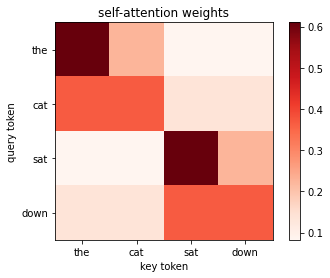

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(self_weights[0].detach().numpy(), cmap="Reds")
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("key token")
plt.ylabel("query token")
plt.title("self-attention weights")
plt.colorbar()
plt.show()

This example is still small and artificial, but the structure is already the same as in a Transformer. Each token asks *which other tokens matter for updating my representation?* Some rows may concentrate on nearby tokens, some may spread more broadly, and some may give strong weight to the token itself. Once we combine self-attention with the multi-head idea, the model can learn several such patterns in parallel. One important issue still remains, however: self-attention by itself does not know the order of tokens.

## Positional Encoding

If we shuffle the same token vectors into a different order, self-attention still computes the same kind of matching, as it has no built-in notion of first, second, or last position. That is a serious problem for language, because order changes meaning. The usual fix in the original Transformer paper is simple: before applying attention, add a position-dependent vector to each token embedding. If the token embedding at position $i$ is $x_i$ and the positional vector is $p_i$, then the actual input to the Transformer layer is $z_i = x_i + p_i$. Here, the vector $x_i$ tells the model *what* the token is, and the vector $p_i$ tells it *where* the token is. Adding them keeps the representation size unchanged, which is convenient because attention layers can then use the same dimension throughout the model.

In [32]:
# Sequence: "The cat sat" (3 tokens, 4-dim embeddings)
X = torch.randn(1, 3, 4)

# Shuffled version: "sat The cat"
indices = [2, 0, 1]
X_shuffled = X[:, indices, :]

# Attention
attn_original = scaled_dot_product_attention(X, X, X)
attn_shuffled = scaled_dot_product_attention(X_shuffled, X_shuffled, X_shuffled)

attn_original[0], attn_shuffled[0]

(tensor([[[ 1.7345,  0.1160,  0.0746,  0.9651],
          [ 1.6001, -0.1974,  0.0715,  0.4042],
          [ 0.9139,  0.6760,  0.1562,  1.2032]]]),
 tensor([[[ 0.9139,  0.6760,  0.1562,  1.2032],
          [ 1.7345,  0.1160,  0.0746,  0.9651],
          [ 1.6001, -0.1974,  0.0715,  0.4042]]]))

When the sequence is shuffled, the attention output is shuffled with it. Nothing inside plain self-attention marks one vector as coming from position 1 and another as coming from position 2. So we need to inject position information explicitly. The original Transformer uses a fixed *sinusoidal positional encoding*. For model dimension $d$, the encoding is defined by
$$
p_{i, 2j} = \sin\!\left(\frac{i}{10000^{2j/d}}\right), \qquad
p_{i, 2j+1} = \cos\!\left(\frac{i}{10000^{2j/d}}\right).
$$
Here $i$ is the token position and $j$ selects the coordinate pair inside the positional vector. The even coordinates use sine and the odd coordinates use cosine. Different coordinates change at different speeds. Low-frequency coordinates vary slowly across positions, while high-frequency coordinates vary more quickly. This gives each position a distinct pattern while keeping the encoding dimension the same as the token embedding dimension.

In [33]:
def positional_encoding(num_positions, d_model):
    positions = torch.arange(num_positions).unsqueeze(1)
    div_term = torch.pow(10000, torch.arange(0, d_model, 2) / d_model)
    P = torch.zeros(num_positions, d_model)
    P[:, 0::2] = torch.sin(positions / div_term)
    P[:, 1::2] = torch.cos(positions / div_term)
    return P

P = positional_encoding(20, 16)
P[:4, :8]

tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.3110,  0.9504,  0.0998,  0.9950,  0.0316,  0.9995],
        [ 0.9093, -0.4161,  0.5911,  0.8066,  0.1987,  0.9801,  0.0632,  0.9980],
        [ 0.1411, -0.9900,  0.8126,  0.5828,  0.2955,  0.9553,  0.0947,  0.9955]])

The next cell visualizes the positional encoding. The line plot helps us see that different coordinates oscillate at different rates. The heatmap then shows the full pattern across positions. Both views matter. The line plot makes the sinusoidal definition concrete, and the heatmap makes it clear that each position receives a distinct vector.

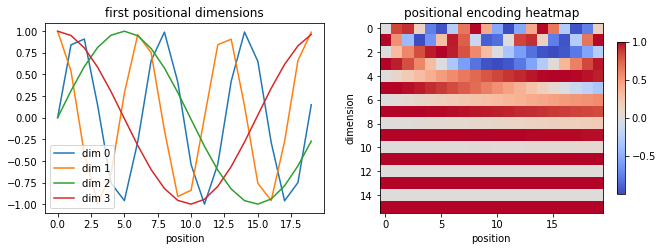

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

for j in range(4):
    axes[0].plot(P[:, j], label=f"dim {j}")
axes[0].set_xlabel("position")
axes[0].set_title("first positional dimensions")
axes[0].legend()

im = axes[1].imshow(P.T, cmap="coolwarm", aspect="auto")
axes[1].set_xlabel("position")
axes[1].set_ylabel("dimension")
axes[1].set_title("positional encoding heatmap")
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.show()

We can now add positional encodings to token embeddings exactly as in $z_i = x_i + p_i$. The next cell uses a very simple embedding matrix so that the effect is easy to read numerically. The token information is still there, but now each position receives an extra offset that depends only on where the token appears in the sequence.

In [36]:
X_tokens = torch.tensor([
    [1.0, 0.5, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0],
])

Z = X_tokens + positional_encoding(X_tokens.size(0), X_tokens.size(1))
Z

tensor([[ 1.0000e+00,  1.5000e+00,  0.0000e+00,  1.0000e+00,  2.0000e-01,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 1.6415e+00,  6.4030e-01,  9.9833e-02,  9.9500e-01,  3.1000e-01,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 1.8093e+00, -2.1615e-01,  1.9867e-01,  9.8007e-01,  4.2000e-01,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 8.4112e-01, -6.8999e-01,  2.9552e-01,  9.5534e-01,  1.3000e-01,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])

After this addition, two identical token embeddings placed at different positions would no longer look identical to the model. That is exactly the point. Self-attention is still responsible for deciding *which* tokens should interact, but positional encoding makes sure the model can also tell *where* those tokens are. At this stage we have the main attention ingredients in place: queries, keys, values, scaled dot-product attention, multi-head attention, self-attention, and positional encoding. The next step is to assemble these ingredients into the actual Transformer block. We will start with the two remaining components that sit around attention in the architecture: the positionwise feed-forward network and the residual-plus-normalization step.

## Positionwise Feed-Forward Networks

So far we have built the attention side of the Transformer. But a Transformer layer is not made of attention alone. In the original architecture, each layer also contains a *positionwise feed-forward network*, and each sublayer is wrapped by a residual connection followed by [layer normalization](../05_cnn_architectures/#batch-normalization). The feed-forward network answers a different question from attention: attention decides which tokens should exchange information, the feed-forward network then processes each token representation separately. So after tokens look at one another through attention, each position goes through the same small multilayer perceptron. If the input at position $i$ is $x_i$, the usual Transformer feed-forward step is
$$
\operatorname{FFN}(x_i)=W_2\,\sigma(W_1 x_i+b_1)+b_2.
$$
This is just a two-layer neural network applied to one token vector at a time. The same weights are reused at every position, which is why it is called *positionwise*. Before defining the feed-forward network as a reusable module, let us first make the idea concrete with a small tensor. The next cell applies the same two-layer transformation to every position in a short sequence. The important thing to notice is that different positions do not interact inside this step. Each row is transformed separately, but the same learned rule is used for every row.

In [ ]:
X = torch.tensor([[
    [1.0, 0.5, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.0],
]])

W1 = torch.tensor([
    [0.5, -0.3, 0.2, 0.1],
    [0.0, 0.4, 0.6, -0.2],
    [0.3, 0.1, -0.5, 0.7],
    [-0.2, 0.2, 0.1, 0.0],
    [0.1, -0.4, 0.3, 0.5],
    [0.6, 0.0, -0.1, 0.2],
])

b1 = torch.tensor([0.1, -0.2, 0.0, 0.1, 0.0, -0.1])

W2 = torch.tensor([
    [0.4, -0.2, 0.1, 0.0, 0.3, 0.2],
    [-0.1, 0.5, 0.2, 0.3, -0.2, 0.1],
    [0.0, 0.1, 0.6, -0.3, 0.2, 0.4],
    [0.2, 0.0, -0.2, 0.5, 0.1, -0.1],
])

b2 = torch.tensor([0.0, 0.1, -0.1, 0.0])

hidden = torch.relu(X @ W1.T + b1)
Y = hidden @ W2.T + b2

X.shape, hidden.shape, Y.shape

The input tensor has shape `(batch_size, num_steps, d_model)` and the output has the same first two dimensions. Only the feature dimension changes inside the hidden layer and then returns to the original width. This is exactly what we want. Attention mixes information across positions, while the feed-forward network reshapes information within each position. The next cell turns this into a small PyTorch module. It is just a two-layer MLP with a ReLU in the middle, applied to the last dimension of the input tensor.

In [ ]:
class PositionwiseFFN(torch.nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = torch.nn.Linear(d_model, d_ff)
        self.linear2 = torch.nn.Linear(d_ff, d_model)

    def forward(self, X):
        return self.linear2(torch.relu(self.linear1(X)))

ffn = PositionwiseFFN(d_model=4, d_ff=8)
Y = ffn(X)
Y.shape

## Add and Norm

The feed-forward network is only one half of the remaining Transformer block. The other half is the *Add & Norm* step. In the original Transformer, each sublayer is wrapped in the pattern
$$
\operatorname{AddNorm}(x, \operatorname{Sublayer}(x))
=
\operatorname{LayerNorm}\bigl(x + \operatorname{Sublayer}(x)\bigr).
$$
This formula has two parts. The addition $x+\operatorname{Sublayer}(x)$ is a residual connection, similar in spirit to [ResNets](../05_cnn_architectures/#residual-networks-resnets). It lets the original input flow forward more directly, which helps optimization. Then `LayerNorm` rescales the result featurewise so that the representation stays numerically well behaved. The next cell shows this pattern with a small tensor. We first create a sublayer output, then add it back to the input, and finally normalize the result along the feature dimension.

In [ ]:
layer_norm = torch.nn.LayerNorm(4)

sublayer_out = ffn(X)
residual_sum = X + sublayer_out
normalized = layer_norm(residual_sum)

X, residual_sum, normalized

The three tensors should be read in order. `X` is the incoming representation, `residual_sum` is the result after adding the sublayer output back to it, and `normalized` is the final output after layer normalization. The residual step means the sublayer is learning a correction to the input rather than a completely new representation from scratch. The normalization step keeps the scale under control at each position. We can now package this into one small module, just as we did for the feed-forward network.

In [ ]:
class AddNorm(torch.nn.Module):
    def __init__(self, d_model, dropout=0.0):
        super().__init__()
        self.dropout = torch.nn.Dropout(dropout)
        self.layer_norm = torch.nn.LayerNorm(d_model)

    def forward(self, X, Y):
        return self.layer_norm(X + self.dropout(Y))

add_norm = AddNorm(d_model=4, dropout=0.0)
Z = add_norm(X, ffn(X))
Z.shape

## Transformer Encoder Block

At this point we have all the pieces needed for the first full Transformer layer. The encoder block in the original architecture takes an input sequence $X$, applies *multi-head self-attention*, wraps it with *Add & Norm*, then applies the *positionwise feed-forward network*, and wraps that result with *Add & Norm* again. In symbols, one encoder block can be written as
$$
H = \operatorname{AddNorm}\bigl(X, \operatorname{MHA}(X, X, X)\bigr), \qquad
Y = \operatorname{AddNorm}\bigl(H, \operatorname{FFN}(H)\bigr).
$$
The notation is compact, but the computation is not new anymore. The term $\operatorname{MHA}(X, X, X)$ means that the block first performs self-attention, so the queries, keys, and values all come from the same input sequence. The first `AddNorm` then adds that attention output back to the input and normalizes it. After that, the feed-forward network processes each token representation separately, and the second `AddNorm` again adds the new result back and normalizes it. So the encoder block is not a mysterious new object. It is just a careful arrangement of the modules we already built.

Before defining the full encoder block, we need one reusable *multi-head attention* module. Earlier we split the representation into heads by hand to make the idea visible. Now we package that idea into a class. The next cell projects the input into queries, keys, and values, splits the last dimension into `num_heads` smaller parts, applies scaled dot-product attention to each head, and then concatenates the head outputs back together. This is the standard Transformer pattern.

In [ ]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.W_q = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_k = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_v = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_o = torch.nn.Linear(d_model, d_model, bias=False)
        self.attention_weights = None

    def split_heads(self, X):
        batch_size, num_steps, _ = X.shape
        X = X.view(batch_size, num_steps, self.num_heads, self.head_dim)
        return X.permute(0, 2, 1, 3)

    def combine_heads(self, X):
        batch_size, num_heads, num_steps, head_dim = X.shape
        X = X.permute(0, 2, 1, 3).contiguous()
        return X.view(batch_size, num_steps, num_heads * head_dim)

    def forward(self, X):
        Q = self.split_heads(self.W_q(X))
        K = self.split_heads(self.W_k(X))
        V = self.split_heads(self.W_v(X))

        batch_size, num_heads, num_steps, head_dim = Q.shape

        Q = Q.reshape(batch_size * num_heads, num_steps, head_dim)
        K = K.reshape(batch_size * num_heads, num_steps, head_dim)
        V = V.reshape(batch_size * num_heads, num_steps, head_dim)

        context, weights = scaled_dot_product_attention(Q, K, V)
        context = context.view(batch_size, num_heads, num_steps, head_dim)
        self.attention_weights = weights.view(batch_size, num_heads, num_steps, num_steps)

        return self.W_o(self.combine_heads(context))

mha = MultiHeadAttention(d_model=4, num_heads=2)
mha_out = mha(X)
mha_out.shape

The output shape is still `(batch_size, num_steps, d_model)`. That is important. Even though the computation inside attention splits the representation into multiple heads, the block returns to the same model width at the end. This makes it possible to stack layers cleanly. We can now wrap multi-head self-attention, feed-forward processing, and the two residual-normalization steps into a single encoder block.

In [ ]:
class TransformerEncoderBlock(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.0):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff)
        self.add_norm2 = AddNorm(d_model, dropout)

    def forward(self, X):
        attention_out = self.attention(X)
        H = self.add_norm1(X, attention_out)
        ffn_out = self.ffn(H)
        return self.add_norm2(H, ffn_out)

X_block = torch.tensor([[
    [1.0, 0.5, 0.0, 0.0],
    [0.8, 0.1, 0.0, 0.0],
    [0.9, 0.2, 0.0, 0.0],
    [0.7, 0.3, 0.0, 0.0],
]], dtype=torch.float32)

X_block = X_block + positional_encoding(X_block.size(1), X_block.size(2)).unsqueeze(0)

encoder_block = TransformerEncoderBlock(d_model=4, num_heads=2, d_ff=8, dropout=0.0)
Y_block = encoder_block(X_block)

X_block.shape, Y_block.shape

Both the input and the output have shape `(1, 4, 4)`. That is exactly what an encoder block should do. It updates each token representation, but it does not change the number of tokens or the model width. The next cell looks inside the block and visualizes the attention weights learned by the two heads for this one example. The weights are not meaningful in the sense of a trained language model yet, because the block is still randomly initialized. But the visualization is useful because it shows the data flow of the encoder block clearly: each head forms its own attention pattern over the same sequence.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

for h in range(2):
    im = axes[h].imshow(encoder_block.attention.attention_weights[0, h].detach().numpy(), cmap="Reds")
    axes[h].set_title(f"head {h + 1}")
    axes[h].set_xlabel("key position")
    axes[h].set_ylabel("query position")

fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

We can now read the Transformer encoder block as a sequence of very familiar steps. Self-attention lets each token gather information from the other tokens. The first `AddNorm` preserves the input through a residual path and stabilizes the representation with layer normalization. The feed-forward network then transforms each token separately, and the second `AddNorm` again adds that update back in. This is why the encoder block is the first real structural unit of the Transformer. It takes the individual ideas from the earlier sections and turns them into one reusable layer. In the next section, we will stack these ideas further and look at the full Transformer encoder and decoder architecture.

## Transformer Decoder Block

The encoder block gave us the first full Transformer layer, but the original model is an *encoder-decoder* architecture. That means the decoder has to do two things at once. It must build a target-side representation from the prefix generated so far, and it must repeatedly consult the encoder output. This is why each decoder block has three sublayers rather than two. If the decoder input at some layer is $X$ and the encoder memory is $E$, then one decoder block can be written as
$$
H_1 = \operatorname{AddNorm}\bigl(X, \operatorname{MaskedMHA}(X, X, X)\bigr),
$$
$$
H_2 = \operatorname{AddNorm}\bigl(H_1, \operatorname{MHA}(H_1, E, E)\bigr),
$$
$$
Y = \operatorname{AddNorm}\bigl(H_2, \operatorname{FFN}(H_2)\bigr).
$$
The first sublayer is *masked self-attention*. It lets target positions communicate with earlier target positions, but it blocks access to future ones. The second sublayer is *cross-attention*. Here the queries come from the decoder, while the keys and values come from the encoder output. The last sublayer is the same positionwise feed-forward network we already studied in the encoder. The only genuinely new idea is the mask. During training we often feed the whole target sentence into the decoder in parallel, but position $t$ still must not use tokens from positions $t+1, t+2, \dots$. So before defining the decoder block itself, let us make that mask concrete.

In [ ]:
def causal_mask(num_queries, num_keys):
    return torch.tril(torch.ones(num_queries, num_keys, dtype=torch.bool))

scores = torch.tensor([[
    [2.0, 1.0, 0.5, -1.0],
    [1.5, 2.5, 1.0, 0.0],
    [0.2, 0.8, 2.0, 1.0],
    [0.1, 0.2, 0.3, 2.0],
]], dtype=torch.float32)

mask = causal_mask(scores.size(-2), scores.size(-1)).unsqueeze(0)
masked_scores = scores.masked_fill(~mask, float("-inf"))
masked_weights = torch.softmax(masked_scores, dim=-1)

mask[0].int(), masked_weights[0]

The lower-triangular pattern is the key point. The first query can only attend to the first key, the second query can only attend to the first two keys, and so on. So causal masking does not change what attention *is*; it only changes which score entries are allowed to survive before the softmax.

Earlier, our reusable `MultiHeadAttention` module assumed self-attention and therefore took only one input sequence. The decoder needs a slightly more general version. It should accept separate query, key, and value tensors, and it should optionally apply a causal mask.

In [ ]:
def scaled_dot_product_attention_masked(Q, K, V, mask=None):
    d = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / (d ** 0.5)
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

The function is almost identical to the earlier scaled dot-product attention. The only difference is that we now allow some score entries to be forcibly removed before normalization. We can now wrap this into a multi-head module that works both for masked decoder self-attention and for encoder-decoder cross-attention.

In [ ]:
class FlexibleMultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.W_q = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_k = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_v = torch.nn.Linear(d_model, d_model, bias=False)
        self.W_o = torch.nn.Linear(d_model, d_model, bias=False)
        self.attention_weights = None

    def split_heads(self, X):
        batch_size, num_steps, _ = X.shape
        X = X.view(batch_size, num_steps, self.num_heads, self.head_dim)
        return X.permute(0, 2, 1, 3)

    def combine_heads(self, X):
        batch_size, num_heads, num_steps, head_dim = X.shape
        X = X.permute(0, 2, 1, 3).contiguous()
        return X.view(batch_size, num_steps, num_heads * head_dim)

    def forward(self, Q_in, K_in, V_in, causal=False):
        Q = self.split_heads(self.W_q(Q_in))
        K = self.split_heads(self.W_k(K_in))
        V = self.split_heads(self.W_v(V_in))

        batch_size, num_heads, num_queries, head_dim = Q.shape
        num_keys = K.shape[2]

        Q = Q.reshape(batch_size * num_heads, num_queries, head_dim)
        K = K.reshape(batch_size * num_heads, num_keys, head_dim)
        V = V.reshape(batch_size * num_heads, num_keys, head_dim)

        mask = None
        if causal:
            mask = causal_mask(num_queries, num_keys).to(Q.device)
            mask = mask.unsqueeze(0).expand(batch_size * num_heads, -1, -1)

        context, weights = scaled_dot_product_attention_masked(Q, K, V, mask=mask)
        context = context.view(batch_size, num_heads, num_queries, head_dim)
        self.attention_weights = weights.view(batch_size, num_heads, num_queries, num_keys)

        return self.W_o(self.combine_heads(context))

With that general attention module in place, the decoder block becomes straightforward. First it performs masked self-attention on the target-side sequence. Then it performs cross-attention from the decoder state into the encoder memory. Finally it applies the feed-forward network. Each sublayer is wrapped by `AddNorm`, just as in the original Transformer description.

In [ ]:
class TransformerDecoderBlock(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.0):
        super().__init__()
        self.self_attention = FlexibleMultiHeadAttention(d_model, num_heads)
        self.add_norm1 = AddNorm(d_model, dropout)
        self.cross_attention = FlexibleMultiHeadAttention(d_model, num_heads)
        self.add_norm2 = AddNorm(d_model, dropout)
        self.ffn = PositionwiseFFN(d_model, d_ff)
        self.add_norm3 = AddNorm(d_model, dropout)

    def forward(self, X, memory):
        self_attended = self.self_attention(X, X, X, causal=True)
        H = self.add_norm1(X, self_attended)
        cross_attended = self.cross_attention(H, memory, memory, causal=False)
        Z = self.add_norm2(H, cross_attended)
        return self.add_norm3(Z, self.ffn(Z))

Let us run the block on one tiny target sequence and one tiny encoder memory. We again add positional encodings so that different positions are distinguishable even when their raw token vectors are similar.

In [ ]:
encoder_memory = torch.tensor([[
    [1.0, 0.5, 0.0, 0.0],
    [0.7, 1.1, 0.0, 0.0],
    [0.2, 0.3, 1.0, 0.0],
    [0.1, 0.2, 0.8, 0.4],
]], dtype=torch.float32)

decoder_input = torch.tensor([[
    [1.0, 0.0, 0.0, 0.0],
    [0.8, 0.2, 0.0, 0.0],
    [0.6, 0.4, 0.0, 0.0],
    [0.4, 0.6, 0.0, 0.0],
]], dtype=torch.float32)

encoder_memory = encoder_memory + positional_encoding(encoder_memory.size(1), encoder_memory.size(2)).unsqueeze(0)
decoder_input = decoder_input + positional_encoding(decoder_input.size(1), decoder_input.size(2)).unsqueeze(0)

decoder_block = TransformerDecoderBlock(d_model=4, num_heads=2, d_ff=8, dropout=0.0)
decoder_output = decoder_block(decoder_input, encoder_memory)

decoder_input.shape, encoder_memory.shape, decoder_output.shape

The three shapes match exactly as they should. The decoder block takes a target-side tensor of shape `(batch_size, num_steps, d_model)`, uses the encoder memory as an additional source of information, and returns another tensor of the same shape. So, like the encoder block, it transforms representations without changing the number of positions or the model width.

What changes internally is the direction of information flow. In the first sublayer, target positions communicate only with the left context. In the second sublayer, every target position can inspect the whole encoder memory. That is the essential difference between decoder self-attention and cross-attention.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for h in range(2):
    im1 = axes[0, h].imshow(decoder_block.self_attention.attention_weights[0, h].detach().numpy(), cmap="Reds")
    axes[0, h].set_title(f"self-attention head {h + 1}")
    axes[0, h].set_xlabel("key position")
    axes[0, h].set_ylabel("query position")

for h in range(2):
    im2 = axes[1, h].imshow(decoder_block.cross_attention.attention_weights[0, h].detach().numpy(), cmap="Reds")
    axes[1, h].set_title(f"cross-attention head {h + 1}")
    axes[1, h].set_xlabel("encoder position")
    axes[1, h].set_ylabel("decoder position")

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

The first row should have no mass above the diagonal. That is the visual fingerprint of causal masking. The second row has no such restriction, because once the encoder has processed the source sequence, every decoder position is allowed to consult every encoder position. At this point the original architecture is structurally complete. We only need to stack encoder blocks and decoder blocks, then add embeddings and an output projection.

## The Full Transformer

We now move from single blocks to the complete encoder-decoder model. The source tokens are embedded, positional information is added, and the encoder stack produces a contextual source sequence. The target tokens are embedded in the same way, and the decoder stack processes them while repeatedly consulting the encoder output. If we write the source-side hidden states as $E^{(\ell)}$ and the target-side hidden states as $D^{(\ell)}$, then the overall structure is
$$
E^{(0)} = X_{\text{src}} + P_{\text{src}}, \qquad E^{(\ell+1)} = \operatorname{EncoderBlock}\bigl(E^{(\ell)}\bigr),
$$
$$
D^{(0)} = X_{\text{tgt}} + P_{\text{tgt}}, \qquad D^{(\ell+1)} = \operatorname{DecoderBlock}\bigl(D^{(\ell)}, E^{(L)}\bigr).
$$
After the last decoder layer, a linear projection maps each decoder state to vocabulary logits. Following the standard Transformer presentation, we will also rescale the embeddings by $\sqrt{d_{\text{model}}}$ before adding positional encodings.

In [ ]:
class TransformerEncoder(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.0):
        super().__init__()
        self.layers = torch.nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, X):
        for layer in self.layers:
            X = layer(X)
        return X

The encoder stack is nothing more than repeated application of the same encoder block. The decoder stack is analogous, except that each layer also receives the encoder memory.

In [ ]:
class TransformerDecoder(torch.nn.Module):
    def __init__(self, d_model, num_heads, d_ff, num_layers, dropout=0.0):
        super().__init__()
        self.layers = torch.nn.ModuleList([
            TransformerDecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, X, memory):
        for layer in self.layers:
            X = layer(X, memory)
        return X

The final wrapper below is deliberately small. It contains source and target embeddings, adds positional encodings, applies the encoder and decoder stacks, and then projects decoder states to vocabulary scores. That is the full forward pass of the original Transformer at the tensor level.

In [ ]:
class TinyTransformer(torch.nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, d_ff, num_layers, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        self.src_embed = torch.nn.Embedding(src_vocab_size, d_model)
        self.tgt_embed = torch.nn.Embedding(tgt_vocab_size, d_model)
        self.encoder = TransformerEncoder(d_model, num_heads, d_ff, num_layers, dropout)
        self.decoder = TransformerDecoder(d_model, num_heads, d_ff, num_layers, dropout)
        self.output_layer = torch.nn.Linear(d_model, tgt_vocab_size)

    def add_position(self, X):
        scale = self.d_model ** 0.5
        P = positional_encoding(X.size(1), X.size(2)).to(X.device).unsqueeze(0)
        return scale * X + P

    def forward(self, src_tokens, tgt_tokens):
        src = self.add_position(self.src_embed(src_tokens))
        tgt = self.add_position(self.tgt_embed(tgt_tokens))
        memory = self.encoder(src)
        decoded = self.decoder(tgt, memory)
        logits = self.output_layer(decoded)
        return logits, memory, decoded

The next cell checks the three central objects in the forward pass: encoder memory, decoder states, and final logits. This is the quickest way to verify that the architecture is wired correctly.

In [ ]:
torch.manual_seed(7)

model = TinyTransformer(
    src_vocab_size=20,
    tgt_vocab_size=30,
    d_model=8,
    num_heads=2,
    d_ff=16,
    num_layers=2,
    dropout=0.0,
)

src_tokens = torch.tensor([[1, 4, 7, 2, 0]])
tgt_tokens = torch.tensor([[1, 5, 9, 3]])

logits, memory, decoded = model(src_tokens, tgt_tokens)
src_tokens.shape, tgt_tokens.shape, memory.shape, decoded.shape, logits.shape

A source sequence of length `5` becomes encoder memory of shape `(1, 5, 8)`. A target sequence of length `4` becomes decoder states of shape `(1, 4, 8)`. After the output projection, each of the `4` target positions receives a vector of `30` vocabulary scores. That is exactly the object used later for the token-level loss.

We can also inspect one encoder attention map and one decoder cross-attention map. The encoder heatmap is square because source positions attend to source positions. The cross-attention heatmap is rectangular in meaning: rows are decoder positions and columns are encoder positions.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))

enc_w = model.encoder.layers[0].attention.attention_weights[0, 0].detach().numpy()
dec_w = model.decoder.layers[0].cross_attention.attention_weights[0, 0].detach().numpy()

im1 = axes[0].imshow(enc_w, cmap="Reds")
axes[0].set_title("encoder self-attention")
axes[0].set_xlabel("key position")
axes[0].set_ylabel("query position")

im2 = axes[1].imshow(dec_w, cmap="Reds")
axes[1].set_title("decoder cross-attention")
axes[1].set_xlabel("encoder position")
axes[1].set_ylabel("decoder position")

fig.colorbar(im2, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

The left heatmap shows one head from the first encoder layer. Since encoder self-attention is not causal, every source position may attend to every other source position. The right heatmap shows one head from the first decoder layer's cross-attention. Each target position decides how strongly it should use each source-side representation. This is the architectural picture introduced by the original Transformer: an encoder stack builds contextual source representations, and a decoder stack uses them while generating the target sequence.

## Training the Transformer

So far we have only sent tensors through the model. Training adds one more ingredient: a target sequence against which the logits are compared. For a sequence-to-sequence Transformer, the decoder does not receive the target sentence in its natural form. Instead, we shift it to the right. The decoder input begins with `<bos>`, and the training target remains the original sequence. This is the usual *teacher forcing* setup.

If the gold target is
$$
\langle y_1, y_2, \dots, y_T, \texttt{<eos>} \rangle,
$$
then the decoder input becomes
$$
\langle \texttt{<bos>}, y_1, y_2, \dots, y_T \rangle.
$$
So at training time, the decoder learns to predict the next token at every position while still obeying the causal mask.

In [ ]:
def shift_right(tgt, bos_id):
    bos = torch.full((tgt.size(0), 1), bos_id, dtype=tgt.dtype)
    return torch.cat([bos, tgt[:, :-1]], dim=1)

The operation is simple but extremely important. It aligns decoder inputs with next-token targets. The final padding token stays padding, so we can later ignore it in the loss.

In [ ]:
def masked_token_loss(logits, targets, pad_id):
    loss = torch.nn.functional.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        targets.reshape(-1),
        reduction="none",
    )
    mask = (targets != pad_id).float().reshape(-1)
    return (loss * mask).sum() / mask.sum()

tgt = torch.tensor([[4, 7, 9, 2, 0]])
tgt_in = shift_right(tgt, bos_id=1)

tgt, tgt_in

We also need a loss that ignores padding positions. The logits are computed for every target position, but padding does not represent a real prediction task. So the loss should only average over non-padding tokens.

To keep the mechanics clear, we will train on a tiny synthetic *copy task*. The source is a short token sequence, and the target is the same sequence followed by `<eos>`. This is not meant to be a serious benchmark. It is just a compact way to test the full encoder-decoder training pipeline.

In [ ]:
torch.manual_seed(3)

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
VOCAB_SIZE = 15

def make_copy_batch(batch_size, seq_len, vocab_size=VOCAB_SIZE):
    src = torch.randint(3, vocab_size, (batch_size, seq_len))
    tgt = torch.cat([
        src,
        torch.full((batch_size, 1), EOS_ID, dtype=torch.long)
    ], dim=1)
    return src, tgt

src_batch, tgt_batch = make_copy_batch(batch_size=4, seq_len=5)
tgt_input = shift_right(tgt_batch, BOS_ID)

src_batch, tgt_batch, tgt_input

The shape pattern already reflects the training setup. If the source length is $5$, the target length is $6$ because we appended `<eos>`. The decoder input also has length $6`, but its first token is `<bos>`.

Now we instantiate a small Transformer and an optimizer. The goal is not to get a powerful model. The goal is to see the training pathway in a form that is compact enough to inspect end to end.

In [ ]:
torch.manual_seed(4)

train_model = TinyTransformer(
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    d_model=16,
    num_heads=4,
    d_ff=32,
    num_layers=2,
    dropout=0.0,
)

optimizer = torch.optim.Adam(train_model.parameters(), lr=0.01)
loss_history = []

In [ ]:
for step in range(60):
    src_batch, tgt_batch = make_copy_batch(batch_size=32, seq_len=5)
    tgt_input = shift_right(tgt_batch, BOS_ID)

    logits, _, _ = train_model(src_batch, tgt_input)
    loss = masked_token_loss(logits, tgt_batch, PAD_ID)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

loss_history[:5], loss_history[-5:]

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training on a tiny copy task")
plt.show()

Even on this toy task, the loss should move downward. That is enough for the architectural point. Encoder input goes through the encoder, shifted targets go through the decoder, and the loss is computed against the unshifted targets.

This also marks an important boundary. During training, the decoder sees the correct previous tokens because we provide them. During inference, those correct future targets are not available. The model must feed its own predictions back into itself one step at a time.

## Autoregressive Inference

The decoder was designed for left-to-right generation. That is why we needed causal masking earlier. At inference time we begin with `<bos>`, run the model, take the prediction for the first position, append it, run the model again, take the next prediction, and continue until `<eos>` appears or a maximum length is reached.

If the generated prefix after step $t-1$ is
$$
\langle \texttt{<bos>}, \hat{y}_1, \hat{y}_2, \dots, \hat{y}_{t-1} \rangle,
$$
then the decoder uses that prefix to produce logits for the next token. This is why inference is called *autoregressive*: the partial output becomes part of the next input.

In [ ]:
def greedy_decode(model, src, bos_id, eos_id, max_new_tokens):
    generated = torch.full((src.size(0), 1), bos_id, dtype=torch.long)

    for _ in range(max_new_tokens):
        logits, _, _ = model(src, generated)
        next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)
        if torch.all(next_token.squeeze(-1) == eos_id):
            break

    return generated

The generated sequence begins with `<bos>` because that token is part of the decoding procedure itself. For comparison with the target, we usually drop that first column and keep only the newly produced tokens.

In [ ]:
test_src, test_tgt = make_copy_batch(batch_size=3, seq_len=5)
pred_tokens = greedy_decode(
    train_model,
    test_src,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    max_new_tokens=6,
)

pred_without_bos = pred_tokens[:, 1:]
comparison = {
    "source": test_src.tolist(),
    "target": test_tgt.tolist(),
    "prediction": pred_without_bos.tolist(),
}
comparison

On a toy task like this, approximate or exact matches are enough to verify that the full path works. Source tokens enter the encoder, the decoder consumes its growing prefix, causal masking blocks future leakage, and the output projection turns decoder states into token scores.

This also clarifies why inference is slower than training. During training, all target positions are processed in parallel because the whole shifted target is already known. During inference, we must generate one position at a time.

## Complexity and Scaling

At this point the architecture itself is in place. What remains is to understand its main computational tradeoff. In self-attention, every position compares itself with every other position. So if the sequence length is $n$, then the attention score matrix for one head has shape
$$
QK^\top \in \mathbb{R}^{n \times n}.
$$
That immediately shows why long-context Transformers are expensive: the number of pairwise interactions grows like $n^2$. For a single self-attention layer, the dominant computation is often summarized as roughly $O(n^2 d)$, where $d$ is the model width. As emphasized in *Attention Is All You Need* (Vaswani et al., 2017), self-attention removes recurrence and shortens the path between distant tokens, but it pays for that with quadratic dependence on sequence length.

In [ ]:
def attention_matrix_elements(seq_len, num_heads=1, batch_size=1):
    return batch_size * num_heads * seq_len * seq_len

for n in [16, 64, 256, 1024]:
    elems = attention_matrix_elements(seq_len=n, num_heads=8, batch_size=2)
    print(f"seq_len={n:4d} -> attention entries={elems:,}")

The growth is the main point. If sequence length doubles, the attention matrix becomes roughly four times larger. We can also estimate raw memory for the attention weights alone. If the weights are stored as 32-bit floating point numbers, then
$$
\text{memory in bytes} = B \cdot H \cdot n^2 \cdot 4,
$$
where $B$ is batch size and $H$ is the number of heads.

In [ ]:
def attention_memory_mb(seq_len, num_heads=8, batch_size=2, bytes_per_value=4):
    total_bytes = batch_size * num_heads * seq_len * seq_len * bytes_per_value
    return total_bytes / (1024 ** 2)

for n in [128, 256, 512, 1024, 2048]:
    print(f"seq_len={n:4d} -> approx attention memory={attention_memory_mb(n):8.2f} MB")

These numbers only describe the attention weights themselves. Real training uses more memory because queries, keys, values, projections, activations, gradients, and optimizer states must also be stored. Still, even this rough estimate already explains why sequence length is such a central practical concern in Transformer engineering.

## Final Recap

We can now summarize the minimal Transformer path in one clean chain.

A token first becomes an embedding vector. Since embeddings alone do not encode order, positional information is added. The encoder repeatedly applies multi-head self-attention, residual connections, layer normalization, and a positionwise feed-forward network. This produces contextualized source representations. The decoder receives a shifted target prefix, applies masked self-attention so that each position can look only to the left, applies cross-attention to consult the encoder output, and then passes the result through another feed-forward sublayer. A final linear projection maps decoder states to vocabulary logits.

The shape trace below is useful as a compact memory aid because it shows the whole flow without extra clutter. At this point the important thing is not to memorize every class name, but to see that the full architecture is just a disciplined composition of a few recurring operations: projections, attention, residual paths, normalization, and positionwise nonlinear transformation.

In [ ]:
summary_shapes = {
    "src_tokens": (2, 5),
    "src_embed_plus_pos": (2, 5, model.d_model),
    "encoder_output": (2, 5, model.d_model),
    "tgt_input_shifted": (2, 6),
    "tgt_embed_plus_pos": (2, 6, train_model.d_model),
    "decoder_output": (2, 6, train_model.d_model),
    "logits": (2, 6, VOCAB_SIZE),
}
summary_shapes

The summary is deliberately minimal, but the architecture should no longer look mysterious. Source tokens become encoder states. Target prefix tokens become decoder states. Decoder states become logits over the vocabulary. Self-attention handles interaction within a sequence, cross-attention lets the decoder consult the encoder, and masking preserves the autoregressive constraint.

This is the main payoff of studying the Transformer step by step. Once the basic flow is clear, most later models become easier to read because they usually modify one part of this pipeline rather than replacing the whole idea. A larger model, a different positional scheme, a faster attention variant, or a new pretraining objective may matter a great deal in practice, but they all sit on top of the same core structure developed in this notebook.

The right stopping point here is simple: you should now be able to read a standard Transformer block, follow the tensor shapes through it, and explain why each sublayer exists. Once that is comfortable, the next topics are no longer “what is attention?” or “what is the encoder doing?”, but rather which part of the baseline architecture a newer paper changes, and what that change is trying to buy.